In [1]:
# Importing neccessary dependencies
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from tqdm import tqdm
from google.colab import drive

In [2]:
# Loading in MNIST Dataset
(train_images, train_labels), (_, _) = keras.datasets.mnist.load_data()
print(train_images.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28)


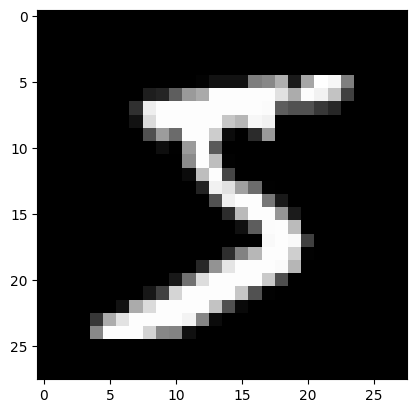

<Figure size 640x480 with 0 Axes>

In [3]:
# Examining the images and the data.
plt.imshow(train_images[0].reshape(28,28), cmap='gray')
plt.show()
plt.clf()

In [4]:
# Global Constants
batch_size = 256
latent_dim = 100
epochs = 500
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [5]:
# Image Preprocessing
def preprocess_images(images):
    images = images.astype('float32')
    images = (images - 127.5) / 127.5  # Normalize to [-1, 1]
    images = np.expand_dims(images, axis=-1)  # Add channel dimension
    return images

train_images = preprocess_images(train_images)

# Optimized tf.data pipeline
BUFFER_SIZE = train_images.shape[0]
# Use the `batch_size` defined in the Globals cell

dataloader = (
    tf.data.Dataset.from_tensor_slices(train_images)
    .shuffle(BUFFER_SIZE)
    .batch(batch_size, drop_remainder=False)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

In [6]:
# Building a Generator Model
def build_generator(noise_dim=100):
    model = keras.Sequential([
        layers.Input(shape=(noise_dim,)),
        layers.Dense(7 * 7 * 256, use_bias=False),
        layers.Reshape((7, 7, 256)),
        layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.Activation('tanh')
    ])
    return model
gen_optimizer = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
generator = build_generator()
generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,280,768 (8.70 MB)

 Trainable params: 2,280,384 (8.70 MB)

 Non-trainable params: 384 (1.50 KB)

In [7]:
# Building a Discriminator Model
def build_discriminator():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(64, (6, 6), strides=(2, 2), padding='same'),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Conv2D(64, (6, 6), strides=(2, 2), padding='same'),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Flatten(),
        layers.Dense(1)
    ])
    return model
disc_optimizer = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator = build_discriminator()
discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         3,137 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,025 (597.75 KB)

 Trainable params: 153,025 (597.75 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Save and Generate Images
drive.mount("/content/drived")
# Change this to your image directory folder.
IMAGE_DIR = "/content/drived/MyDrive/Generative_Image_Project/Generated_Images"

# Ensure the directory exists
os.makedirs(IMAGE_DIR, exist_ok=True)
print(f"Images will be saved to: {IMAGE_DIR}")

def generate_and_save_images(model, epoch, test_input):
    # Notice `training` is set to False.
    # This is so all layers run in inference mode (batchnorm).
    predictions = model(test_input, training=False)

    # De-normalize images
    predictions = (predictions * 127.5 + 127.5) / 255.0  # Normalize to [0, 1]

    # Save images to disk
    num_images = predictions.shape[0]
    cols = int(np.sqrt(num_images))
    rows = int(np.ceil(num_images / cols))

    fig = plt.figure(figsize=(cols, rows))
    for i in range(predictions.shape[0]):
        plt.subplot(rows, cols, i+1)
        plt.imshow(predictions[i, :, :, 0], cmap='gray')
        plt.axis('off')

    # The IMAGE_DIR is now a global variable defined in a previous cell.
    image_path = os.path.join(IMAGE_DIR, 'image_at_epoch_{:04d}.png'.format(epoch))
    try:
        plt.savefig(image_path)
        print(f'✓ Images saved to: {image_path}')
    except Exception as e:
        print(f'Error saving images at epoch {epoch}: {str(e)}')
    finally:
        plt.close(fig)

Mounted at /content/drived
Images will be saved to: /content/drived/MyDrive/Generative_Image_Project/Generated_Images


In [9]:
# Checkpointing and Metrics
gen_loss_metric = tf.keras.metrics.Mean(name='gen_loss')
disc_loss_metric = tf.keras.metrics.Mean(name='disc_loss')

# Checkpointing to resume training
checkpoint_dir = os.path.join(os.getcwd(), 'training_checkpoints')
checkpoint = tf.train.Checkpoint(generator=generator,
                                 discriminator=discriminator,
                                 gen_optimizer=gen_optimizer,
                                 disc_optimizer=disc_optimizer)
checkpoint_manager = tf.train.CheckpointManager(checkpoint, checkpoint_dir, max_to_keep=5)

print('Checkpoint directory:', checkpoint_dir)

Checkpoint directory: /content/training_checkpoints


In [10]:
# Training Loop
@tf.function
def train_step(images):
    # dynamic batch size for the last (smaller) batch
    current_bs = tf.shape(images)[0]
    noise = tf.random.normal([current_bs, latent_dim])

    # label smoothing for real labels
    real_label = 0.9
    fake_label = 0.0

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # Smoothed labels for discriminator
        real_labels_for_loss = tf.fill(tf.shape(real_output), real_label)
        fake_labels_for_loss = tf.fill(tf.shape(fake_output), fake_label)

        # Compute losses
        gen_loss = cross_entropy(tf.ones_like(fake_output), fake_output)
        disc_real_loss = cross_entropy(real_labels_for_loss, real_output)
        disc_fake_loss = cross_entropy(fake_labels_for_loss, fake_output)
        disc_loss = disc_real_loss + disc_fake_loss

    # Gradients
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # Optimization Step: Update Weights
    gen_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    # Update metrics
    gen_loss_metric.update_state(gen_loss)
    disc_loss_metric.update_state(disc_loss)

    return gen_loss, disc_loss

# Create seed for image generation
seed = tf.random.normal([16, latent_dim])
# Training loop using metrics and checkpointing
for epoch in range(epochs):

    gen_loss_metric.reset_state()
    disc_loss_metric.reset_state()

    # The inner loop runs the training steps
    for image_batch in tqdm(dataloader, desc=f"Epoch {epoch + 1}"):
        g_loss, d_loss = train_step(image_batch)

    # Print progress
    print(f'Epoch {epoch + 1}, Gen Loss: {gen_loss_metric.result().numpy():.4f}, Disc Loss: {disc_loss_metric.result().numpy():.4f}')
    # Save checkpoint and generated images every few epochs
    if (epoch + 1) % 10 == 0:
        checkpoint_manager.save()
        generate_and_save_images(generator, epoch + 1, seed)

Epoch 1: 100%|██████████| 235/235 [00:15<00:00, 14.88it/s]


Epoch 1, Gen Loss: 0.7806, Disc Loss: 1.2867


Epoch 2: 100%|██████████| 235/235 [00:09<00:00, 25.14it/s]


Epoch 2, Gen Loss: 0.8756, Disc Loss: 1.3039


Epoch 3: 100%|██████████| 235/235 [00:09<00:00, 24.84it/s]


...

Epoch 498, Gen Loss: 1.2336, Disc Loss: 1.1485


Epoch 499: 100%|██████████| 235/235 [00:09<00:00, 25.30it/s]


Epoch 499, Gen Loss: 1.2296, Disc Loss: 1.1462


Epoch 500: 100%|██████████| 235/235 [00:09<00:00, 25.29it/s]


Epoch 500, Gen Loss: 1.2326, Disc Loss: 1.1504
✓ Images saved to: /content/drived/MyDrive/Generative_Image_Project/Generated_Images/image_at_epoch_0500.png
